In [1]:
import pandas as pd

# Option 1: Using a raw string (recommended)
file_path = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\Porter Optimizing Delivery Project\Dataset\dataset.csv"

# Option 2: Using forward slashes
# file_path = "C:/Users/mukhe/OneDrive/Documents/Jobaaj_DA Projects/Porter Optimizing Delivery Project/Dataset/dataset.csv"

# Load the dataset
df = pd.read_csv(file_path)

# View the first few rows to confirm it loaded correctly
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [2]:
# 1. Check the count of missing values for the specific columns
target_missing_cols = [
    'market_id', 'actual_delivery_time', 'store_primary_category', 
    'order_protocol', 'total_onshift_partners', 'total_busy_partners', 
    'total_outstanding_orders'
]

print("--- Missing Values Count ---")
print(df[target_missing_cols].isnull().sum())

print("\n--- Missing Values Percentage ---")
print((df[target_missing_cols].isnull().sum() / len(df)) * 100)

--- Missing Values Count ---
market_id                     987
actual_delivery_time            7
store_primary_category       4760
order_protocol                995
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
dtype: int64

--- Missing Values Percentage ---
market_id                   0.499929
actual_delivery_time        0.003546
store_primary_category      2.411006
order_protocol              0.503981
total_onshift_partners      8.236927
total_busy_partners         8.236927
total_outstanding_orders    8.236927
dtype: float64


In [3]:
# 2. Handle missing data based on standard analytical practices

# Drop rows where critical target information is missing
df_cleaned = df.dropna(subset=['actual_delivery_time']).copy()

# Impute categorical nulls with a placeholder string
cat_cols = ['market_id', 'store_primary_category', 'order_protocol']
for col in cat_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# Impute numerical partner/order metrics with their median values
num_cols = ['total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders']
for col in num_cols:
    if col in df_cleaned.columns:
        median_value = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_value)

# Verify that no missing values remain in these fields
print("Remaining null values:")
print(df_cleaned[target_missing_cols].isnull().sum())

Remaining null values:
market_id                   0
actual_delivery_time        0
store_primary_category      0
order_protocol              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
dtype: int64


In [4]:
# 1. Convert timestamps from string to datetime objects
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'], errors='coerce')
df_cleaned['actual_delivery_time'] = pd.to_datetime(df_cleaned['actual_delivery_time'], errors='coerce')

# Drop any rows where the conversion failed and resulted in NaT (Not a Time)
df_cleaned = df_cleaned.dropna(subset=['created_at', 'actual_delivery_time']).copy()

# 2. Calculate Delivery Duration in minutes
# (Subtracting 'created_at' from 'actual_delivery_time' and extracting total seconds)
df_cleaned['delivery_duration'] = (df_cleaned['actual_delivery_time'] - df_cleaned['created_at']).dt.total_seconds() / 60.0

# 3. Extract Day of the Week (0 = Monday, 6 = Sunday)
df_cleaned['day_of_the_week'] = df_cleaned['created_at'].dt.dayofweek

# 4. Extract Hour of the Day (0 to 23)
df_cleaned['hour_of_the_day'] = df_cleaned['created_at'].dt.hour

# Verify the changes and preview the new columns
print("Data types after conversion:")
print(df_cleaned[['created_at', 'actual_delivery_time']].dtypes)
print("\nPreview of engineered features:")
df_cleaned[['created_at', 'actual_delivery_time', 'delivery_duration', 'day_of_the_week', 'hour_of_the_day']].head()

Data types after conversion:
created_at              datetime64[ns]
actual_delivery_time    datetime64[ns]
dtype: object

Preview of engineered features:


,created_at,actual_delivery_time,delivery_duration,day_of_the_week,hour_of_the_day
0,2015-02-06 22:24:17,2015-02-06 23:27:16,62.983333,4,22
1,2015-02-10 21:49:25,2015-02-10 22:56:29,67.066667,1,21
2,2015-01-22 20:39:28,2015-01-22 21:09:09,29.683333,3,20
3,2015-02-03 21:21:45,2015-02-03 22:13:00,51.250000,1,21
4,2015-02-15 02:40:36,2015-02-15 03:20:26,39.833333,6,2


In [5]:
# 1. Inspect the number of unique categories and their frequencies
unique_count = df_cleaned['store_primary_category'].nunique()
print(f"Total unique categories before simplification: {unique_count}\n")

print("Top 15 most frequent categories:")
print(df_cleaned['store_primary_category'].value_counts().head(15))

# 2. Define a threshold for simplification
# Categories contributing less than 1% of total orders will be grouped into 'Other'
threshold = 0.01 
category_counts = df_cleaned['store_primary_category'].value_counts(normalize=True)

# Identify categories that fall below the threshold
minor_categories = category_counts[category_counts < threshold].index

# 3. Simplify by mapping minor categories to 'Other'
df_cleaned['store_primary_category'] = df_cleaned['store_primary_category'].replace(minor_categories, 'Other')

# Verify the changes
print(f"\nTotal unique categories after simplification: {df_cleaned['store_primary_category'].nunique()}")
print("\nNew distribution of categories:")
print(df_cleaned['store_primary_category'].value_counts())

Total unique categories before simplification: 75

Top 15 most frequent categories:
store_primary_category
american         19399
pizza            17320
mexican          17098
burger           10958
sandwich         10059
chinese           9421
japanese          9195
dessert           8772
fast              7371
indian            7314
thai              7225
italian           7179
vietnamese        6095
mediterranean     5512
breakfast         5425
Name: count, dtype: int64

Total unique categories after simplification: 25

New distribution of categories:
store_primary_category
Other            20942
american         19399
pizza            17320
mexican          17098
burger           10958
sandwich         10059
chinese           9421
japanese          9195
dessert           8772
fast              7371
indian            7314
thai              7225
italian           7179
vietnamese        6095
mediterranean     5512
breakfast         5425
Unknown           4760
other             3988
sa

### Basic Level Topics

Solution for basic level topic 1

--- Order Volume Distribution by Market ---
Market ID 2.0: 55055 orders (27.89%)
Market ID 4.0: 47597 orders (24.11%)
Market ID 1.0: 38037 orders (19.27%)
Market ID 3.0: 23296 orders (11.80%)
Market ID 5.0: 17999 orders (9.12%)
Market ID 6.0: 14450 orders (7.32%)
Market ID Unknown: 987 orders (0.50%)


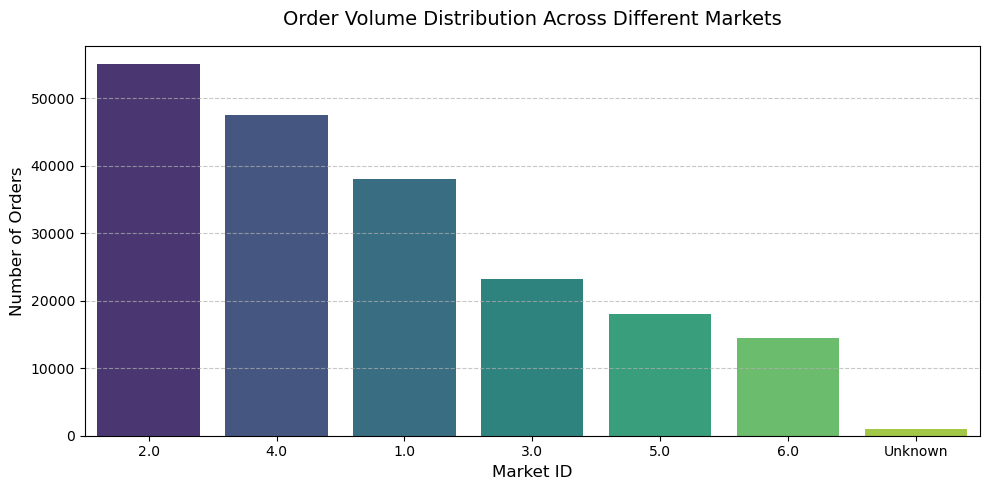

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Header statement as requested
print("Solution for basic level topic 1\n")

# 1. Calculate the distribution of order volumes across different markets
market_distribution = df_cleaned['market_id'].value_counts()
market_percentage = df_cleaned['market_id'].value_counts(normalize=True) * 100

# 2. Display the data summary
print("--- Order Volume Distribution by Market ---")
for market, count in market_distribution.items():
    pct = market_percentage[market]
    print(f"Market ID {market}: {count} orders ({pct:.2f}%)")

# 3. Create a clean visualization (Fixed to completely suppress the FutureWarning)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=market_distribution.index, 
    y=market_distribution.values, 
    hue=market_distribution.index,   # Assigns the x variable to hue to fix the warning
    palette='viridis', 
    legend=False                     # Removers the redundant color legend
)

plt.title('Order Volume Distribution Across Different Markets', fontsize=14, pad=15)
plt.xlabel('Market ID', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 2

--- Average Delivery Duration (Minutes) by Store Category ---
store_primary_category
italian          70.200889
japanese         52.077584
sushi            51.519921
pizza            50.869166
salad            50.173262
indian           49.735514
dessert          48.791450
Unknown          48.721471
thai             48.620263
chinese          48.067650
american         47.758619
Other            47.754879
barbecue         47.584729
greek            47.544257
seafood          47.464255
asian            47.271090
burger           47.175414
mediterranean    46.930264
other            46.126350
cafe             45.845895
vietnamese       45.344728
breakfast        44.990111
sandwich         44.760702
mexican          44.546868
fast             43.853606
Name: delivery_duration, dtype: float64


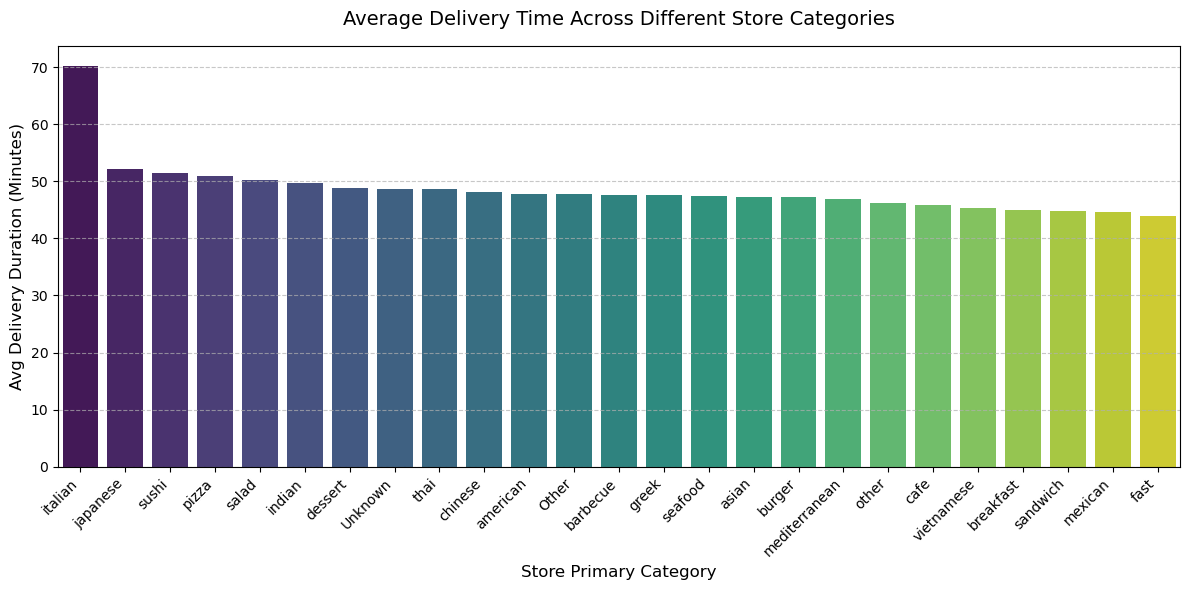

In [7]:
# Header statement as requested
print("Solution for basic level topic 2\n")

# 1. Group the data by store_primary_category and calculate the average delivery duration
category_delivery = df_cleaned.groupby('store_primary_category')['delivery_duration'].mean().sort_values(ascending=False)

# 2. Display the data summary
print("--- Average Delivery Duration (Minutes) by Store Category ---")
print(category_delivery)

# 3. Create a clean visualization (Fixed to prevent the FutureWarning)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_delivery.index, 
    y=category_delivery.values, 
    hue=category_delivery.index,  # Maps hue to suppress warning
    palette='viridis', 
    legend=False                  # Hides the redundant legend block
)

plt.title('Average Delivery Time Across Different Store Categories', fontsize=14, pad=15)
plt.xlabel('Store Primary Category', fontsize=12)
plt.ylabel('Avg Delivery Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Tilts category names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 3

--- Order Volume by Hour of the Day ---
Hour 00:00 -> 12669 orders
Hour 01:00 -> 28187 orders
Hour 02:00 -> 36973 orders
Hour 03:00 -> 27068 orders
Hour 04:00 -> 15250 orders
Hour 05:00 -> 7096 orders
Hour 06:00 -> 1416 orders
Hour 07:00 -> 11 orders
Hour 08:00 -> 2 orders
Hour 14:00 -> 40 orders
Hour 15:00 -> 538 orders
Hour 16:00 -> 2109 orders
Hour 17:00 -> 3413 orders
Hour 18:00 -> 5100 orders
Hour 19:00 -> 13541 orders
Hour 20:00 -> 15560 orders
Hour 21:00 -> 11464 orders
Hour 22:00 -> 8821 orders
Hour 23:00 -> 8163 orders


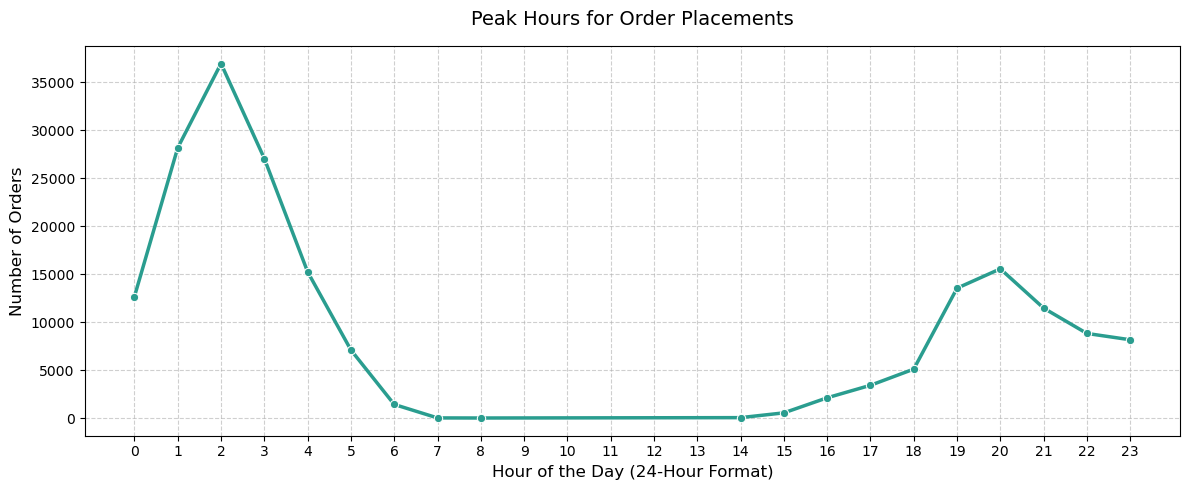

In [8]:
# Header statement as requested
print("Solution for basic level topic 3\n")

# 1. Count the number of orders placed in each hour
hourly_orders = df_cleaned['hour_of_the_day'].value_counts().sort_index()

# 2. Display the data summary in text format
print("--- Order Volume by Hour of the Day ---")
for hour, count in hourly_orders.items():
    print(f"Hour {hour:02d}:00 -> {count} orders")

# 3. Create a clean line plot to visualize temporal trends
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=hourly_orders.index, 
    y=hourly_orders.values, 
    marker='o', 
    color='#2a9d8f', 
    linewidth=2.5
)

plt.title('Peak Hours for Order Placements', fontsize=14, pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(range(0, 24))  # Ensures every single hour from 0 to 23 is marked
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 4

--- Order Volume by Day of the Week ---
Monday: 27402 orders (13.88%)
Tuesday: 24061 orders (12.19%)
Wednesday: 24254 orders (12.29%)
Thursday: 25673 orders (13.00%)
Friday: 27875 orders (14.12%)
Saturday: 34541 orders (17.50%)
Sunday: 33615 orders (17.03%)


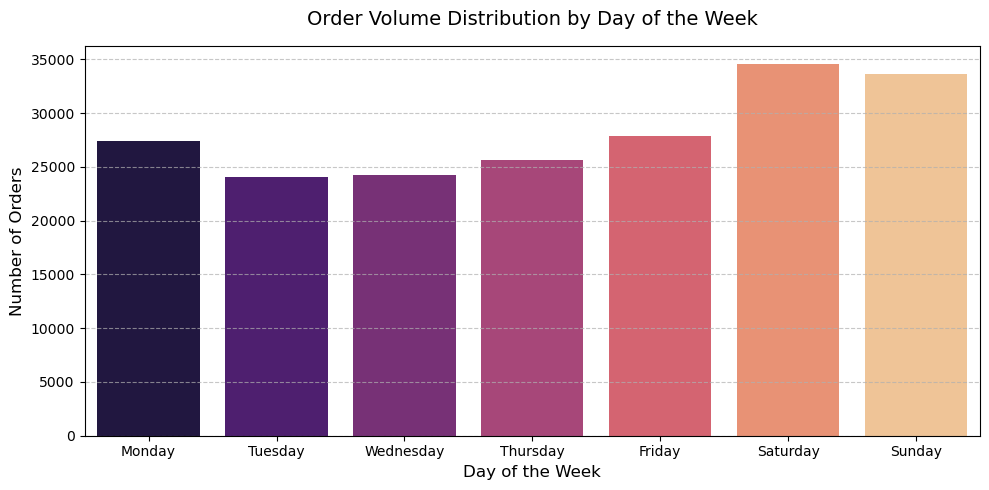

In [9]:
# Header statement as requested
print("Solution for basic level topic 4\n")

# 1. Map the day numbers (0-6) to readable day names
day_names = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

# 2. Count orders by day and map names
daily_orders = df_cleaned['day_of_the_week'].value_counts().sort_index()
daily_orders.index = daily_orders.index.map(day_names)

# Calculate percentages for text summary
daily_percentage = (daily_orders / daily_orders.sum()) * 100

# 3. Display the data summary
print("--- Order Volume by Day of the Week ---")
for day, count in daily_orders.items():
    pct = daily_percentage[day]
    print(f"{day}: {count} orders ({pct:.2f}%)")

# 4. Create a clean bar chart with correct hue mapping to suppress warnings
plt.figure(figsize=(10, 5))
sns.barplot(
    x=daily_orders.index, 
    y=daily_orders.values, 
    hue=daily_orders.index, 
    palette='magma', 
    legend=False
)

plt.title('Order Volume Distribution by Day of the Week', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 5

Correlation coefficient between total items and subtotal: 0.5581
Interpretation: Moderate positive correlation



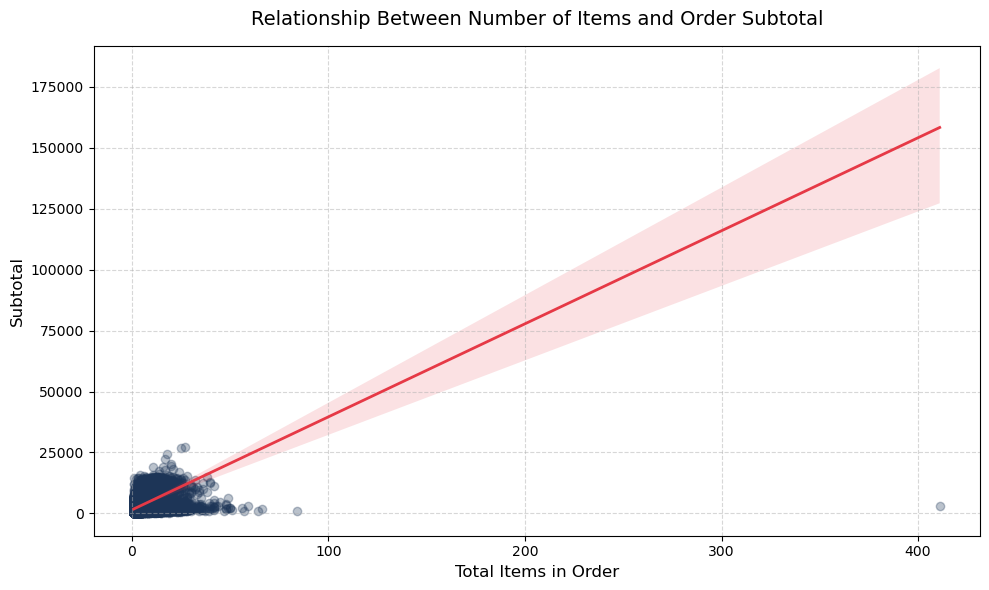

In [10]:
# Header statement as requested
print("Solution for basic level topic 5\n")

# 1. Calculate the Pearson correlation coefficient
correlation_value = df_cleaned['total_items'].corr(df_cleaned['subtotal'])
print(f"Correlation coefficient between total items and subtotal: {correlation_value:.4f}")

# Interpret the strength of the relationship
if correlation_value > 0.7:
    strength = "Strong positive correlation"
elif correlation_value > 0.4:
    strength = "Moderate positive correlation"
elif correlation_value > 0:
    strength = "Weak positive correlation"
else:
    strength = "No or negative correlation"
print(f"Interpretation: {strength}\n")

# 2. Create a scatter plot with a regression line to show the trend
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned, 
    x='total_items', 
    y='subtotal', 
    scatter_kws={'alpha':0.3, 'color': '#1d3557'}, 
    line_kws={'color': '#e63946', 'linewidth': 2}
)

plt.title('Relationship Between Number of Items and Order Subtotal', fontsize=14, pad=15)
plt.xlabel('Total Items in Order', fontsize=12)
plt.ylabel('Subtotal', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 6

--- Delivery Duration Outlier Analysis ---
25th Percentile (Q1): 35.07 minutes
75th Percentile (Q3): 56.35 minutes
Outlier Threshold Boundary: Anything above 88.28 minutes
Total outlier orders identified: 6278 (3.18% of total data)


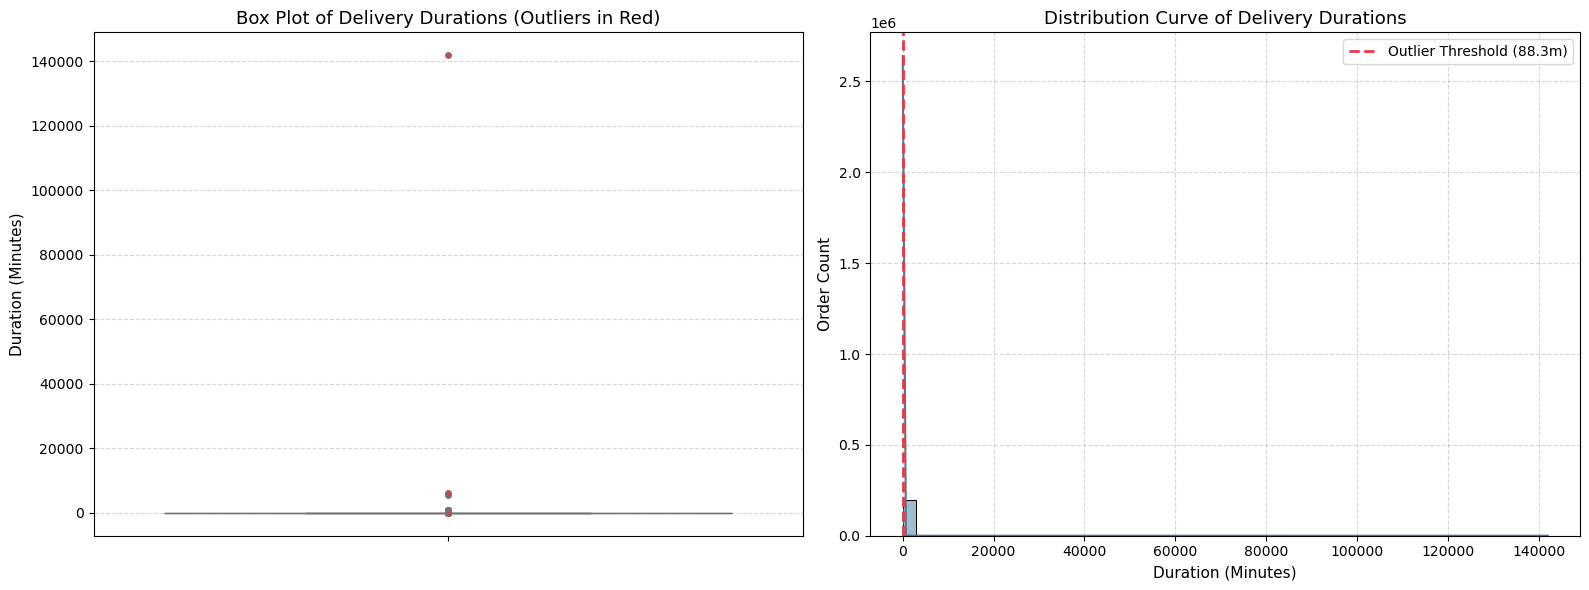

In [11]:
import numpy as np

# Header statement as requested
print("Solution for basic level topic 6\n")

# 1. Calculate statistical boundaries using the IQR method
Q1 = df_cleaned['delivery_duration'].quantile(0.25)
Q3 = df_cleaned['delivery_duration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract outliers
outliers = df_cleaned[(df_cleaned['delivery_duration'] < lower_bound) | (df_cleaned['delivery_duration'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df_cleaned)) * 100

print(f"--- Delivery Duration Outlier Analysis ---")
print(f"25th Percentile (Q1): {Q1:.2f} minutes")
print(f"75th Percentile (Q3): {Q3:.2f} minutes")
print(f"Outlier Threshold Boundary: Anything above {upper_bound:.2f} minutes")
print(f"Total outlier orders identified: {len(outliers)} ({outlier_percentage:.2f}% of total data)")

# 3. Create side-by-side visualizations (Box Plot and Distribution Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box Plot to explicitly highlight individual outlier points
sns.boxplot(
    ax=axes[0],
    y=df_cleaned['delivery_duration'], 
    color='#a8dadc',
    flierprops={'markerfacecolor': '#e63946', 'marker': 'o', 'markersize': 4}
)
axes[0].set_title('Box Plot of Delivery Durations (Outliers in Red)', fontsize=13)
axes[0].set_ylabel('Duration (Minutes)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Histogram to see the distribution curve shape
sns.histplot(
    ax=axes[1],
    data=df_cleaned, 
    x='delivery_duration', 
    bins=50, 
    kde=True, 
    color='#457b9d'
)
axes[1].axvline(upper_bound, color='#e63946', linestyle='--', linewidth=2, label=f'Outlier Threshold ({upper_bound:.1f}m)')
axes[1].set_title('Distribution Curve of Delivery Durations', fontsize=13)
axes[1].set_xlabel('Duration (Minutes)', fontsize=11)
axes[1].set_ylabel('Order Count', fontsize=11)
axes[1].legend()
axes[1].grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Solution for basic level topic 7

--- 30-Minute Delivery Window Analysis ---
Total orders evaluated: 197,421
Deliveries completed within 30 mins: 25,976 (13.16%)
Deliveries taking longer than 30 mins: 171,445 (86.84%)


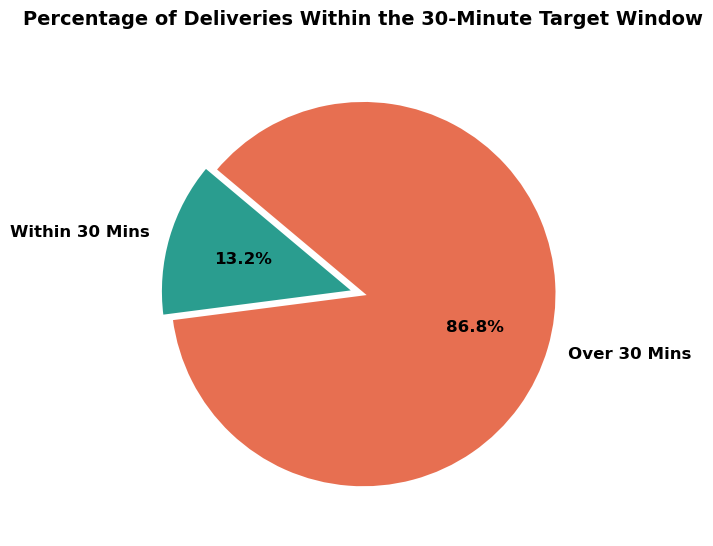

In [12]:
# Header statement as requested
print("Solution for basic level topic 7\n")

# 1. Calculate compliance metrics against the 30-minute delivery goal
within_30_mins = df_cleaned[df_cleaned['delivery_duration'] <= 30.0]
total_orders = len(df_cleaned)

on_time_count = len(within_30_mins)
delayed_count = total_orders - on_time_count

on_time_pct = (on_time_count / total_orders) * 100
delayed_pct = (delayed_count / total_orders) * 100

print(f"--- 30-Minute Delivery Window Analysis ---")
print(f"Total orders evaluated: {total_orders:,}")
print(f"Deliveries completed within 30 mins: {on_time_count:,} ({on_time_pct:.2f}%)")
print(f"Deliveries taking longer than 30 mins: {delayed_count:,} ({delayed_pct:.2f}%)")

# 2. Build a clear visual donut/pie chart for stakeholder presentations
plt.figure(figsize=(7, 7))
labels = ['Within 30 Mins', 'Over 30 Mins']
sizes = [on_time_pct, delayed_pct]
colors = ['#2a9d8f', '#e76f51']  # Clean teal for on-time, soft coral for delayed
explode = (0.05, 0)  # slightly separate the primary metric slice

plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140, 
    textprops={'fontsize': 12, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Percentage of Deliveries Within the 30-Minute Target Window', fontsize=14, pad=20, weight='bold')

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 8

--- Order Volume by Number of Busy Partners ---
Busy Partners: -5 -> 1 orders
Busy Partners: -4 -> 2 orders
Busy Partners: -3 -> 2 orders
Busy Partners: -2 -> 3 orders
Busy Partners: -1 -> 13 orders
Busy Partners: 00 -> 4171 orders
Busy Partners: 01 -> 1596 orders
Busy Partners: 02 -> 2286 orders
Busy Partners: 03 -> 2644 orders
Busy Partners: 04 -> 2841 orders
Busy Partners: 05 -> 2930 orders
Busy Partners: 06 -> 3040 orders
Busy Partners: 07 -> 2923 orders
Busy Partners: 08 -> 2977 orders
Busy Partners: 09 -> 2934 orders
Busy Partners: 10 -> 3114 orders
Busy Partners: 11 -> 2981 orders
Busy Partners: 12 -> 2954 orders
Busy Partners: 13 -> 3052 orders
Busy Partners: 14 -> 2916 orders
Busy Partners: 15 -> 2920 orders
Busy Partners: 16 -> 2935 orders
Busy Partners: 17 -> 2868 orders
Busy Partners: 18 -> 3001 orders
Busy Partners: 19 -> 2789 orders
Busy Partners: 20 -> 2563 orders
Busy Partners: 21 -> 2556 orders
Busy Partners: 22 -> 2547 orders
Busy Par

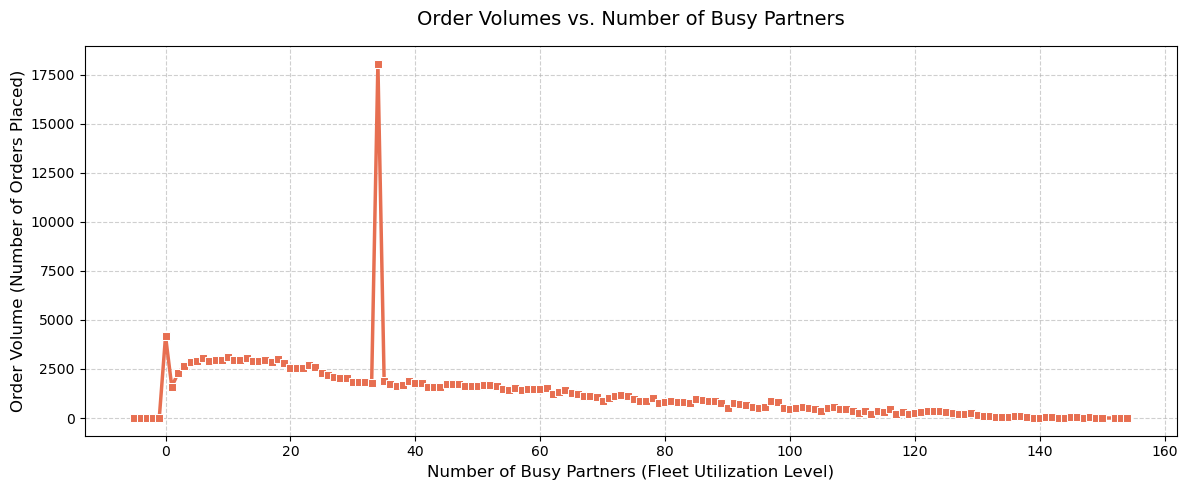

In [13]:
# Header statement as requested
print("Solution for basic level topic 8\n")

# 1. Calculate order volume (count of orders) grouped by the number of busy partners
busy_partners_volume = df_cleaned['total_busy_partners'].value_counts().sort_index()

# 2. Display the data summary in text format
print("--- Order Volume by Number of Busy Partners ---")
for busy_count, order_vol in busy_partners_volume.items():
    print(f"Busy Partners: {int(busy_count):02d} -> {order_vol} orders")

# 3. Create a trend plot to visualize how volumes change with driver busyness
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=busy_partners_volume.index, 
    y=busy_partners_volume.values, 
    marker='s', 
    color='#e76f51', 
    linewidth=2.5
)

plt.title('Order Volumes vs. Number of Busy Partners', fontsize=14, pad=15)
plt.xlabel('Number of Busy Partners (Fleet Utilization Level)', fontsize=12)
plt.ylabel('Order Volume (Number of Orders Placed)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 9

--- Average Delivery Duration (Minutes) by Day of the Week ---
Monday: 51.71 minutes
Tuesday: 46.33 minutes
Wednesday: 44.47 minutes
Thursday: 47.10 minutes
Friday: 44.75 minutes
Saturday: 50.09 minutes
Sunday: 52.72 minutes


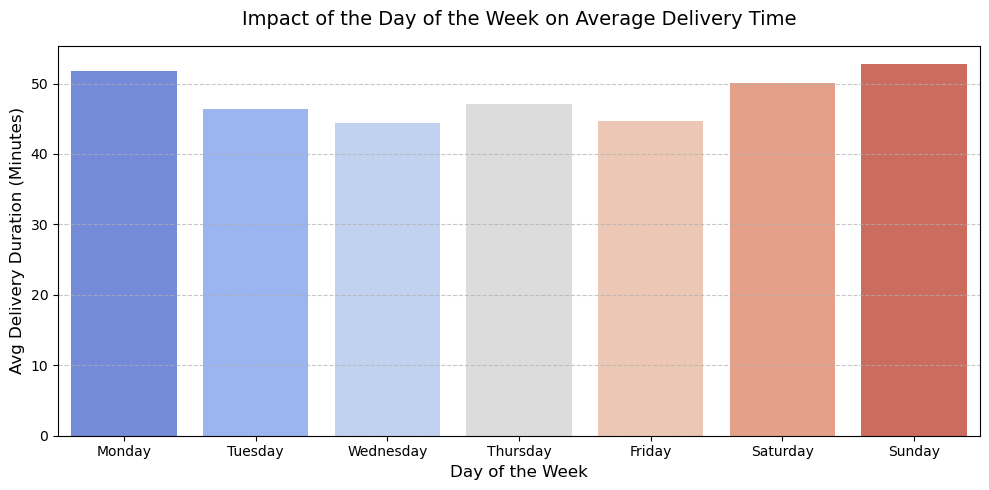

In [14]:
# Header statement as requested
print("Solution for basic level topic 9\n")

# 1. Map the numeric days to string names for clear labeling
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

# 2. Group by day of the week and calculate mean delivery time
weekly_delivery_avg = df_cleaned.groupby('day_of_the_week')['delivery_duration'].mean().sort_index()
weekly_delivery_avg.index = weekly_delivery_avg.index.map(day_names)

# 3. Display the text summary
print("--- Average Delivery Duration (Minutes) by Day of the Week ---")
for day in day_order:
    if day in weekly_delivery_avg.index:
        print(f"{day}: {weekly_delivery_avg[day]:.2f} minutes")

# 4. Create a bar plot structured to suppress modern Seaborn warnings
plt.figure(figsize=(10, 5))
sns.barplot(
    x=weekly_delivery_avg.index, 
    y=weekly_delivery_avg.values, 
    order=day_order,
    hue=weekly_delivery_avg.index,
    palette='coolwarm', 
    legend=False
)

plt.title('Impact of the Day of the Week on Average Delivery Time', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Avg Delivery Duration (Minutes)', fontsize=12)
plt.ylim(bottom=0)  # Ensures the y-axis starts exactly at zero
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 10

--- Top 5 Stores with Longest Average Delivery Times ---
Store ID 675f9820626f5bc0afb47b57890b466e: 8407.30 minutes
Store ID d397c2b2be2178fe6247bd50fc97cff2: 325.03 minutes
Store ID 9ce3c52fc54362e22053399d3181c638: 90.48 minutes
Store ID bfc73dd2bd4da1dda729c02c9cfa4dea: 89.98 minutes
Store ID 2d2c8394e31101a261abf1784302bf75: 84.05 minutes


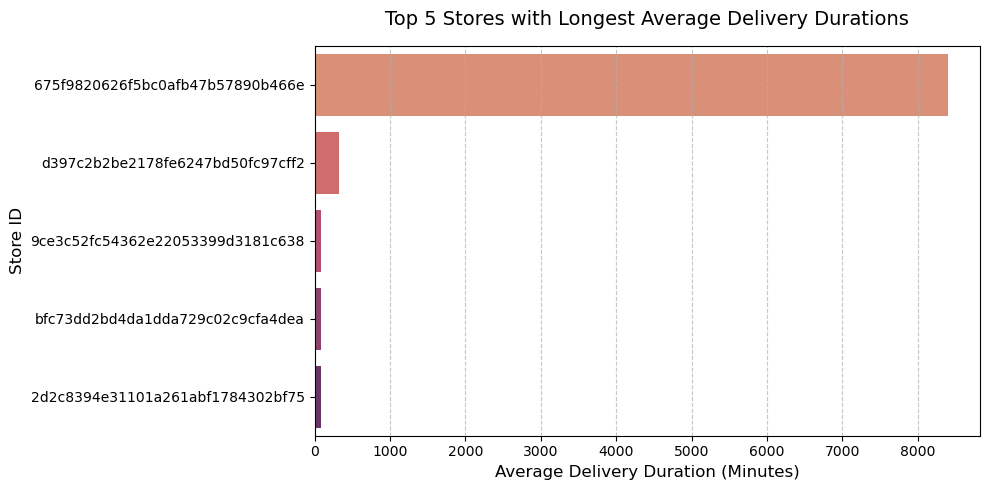

In [15]:
# Header statement as requested
print("Solution for basic level topic 10\n")

# 1. Filter out stores with fewer than 10 orders to ensure statistical reliability
min_orders = 10
store_counts = df_cleaned['store_id'].value_counts()
reliable_stores = store_counts[store_counts >= min_orders].index

df_reliable = df_cleaned[df_cleaned['store_id'].isin(reliable_stores)]

# 2. Calculate average delivery time per store and grab the top 5 longest
top_5_slowest_stores = df_reliable.groupby('store_id')['delivery_duration'].mean().sort_values(ascending=False).head(5)

# 3. Display the data summary
print("--- Top 5 Stores with Longest Average Delivery Times ---")
for store_id, duration in top_5_slowest_stores.items():
    print(f"Store ID {store_id}: {duration:.2f} minutes")

# 4. Create a clean horizontal bar chart (Fixed for modern Seaborn warning)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_5_slowest_stores.values, 
    y=top_5_slowest_stores.index.astype(str),  # Convert to string for clear discrete labels
    hue=top_5_slowest_stores.index.astype(str),
    palette='flare', 
    legend=False
)

plt.title('Top 5 Stores with Longest Average Delivery Durations', fontsize=14, pad=15)
plt.xlabel('Average Delivery Duration (Minutes)', fontsize=12)
plt.ylabel('Store ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for basic level topic 10

--- Top 5 Stores with Longest Average Delivery Times ---
Store A (ID: 2d2c8394...): 84.05 minutes
Store B (ID: 708f3cf8...): 83.93 minutes
Store C (ID: a87c11b9...): 83.83 minutes
Store D (ID: bfc73dd2...): 83.00 minutes
Store E (ID: 30da227c...): 82.83 minutes


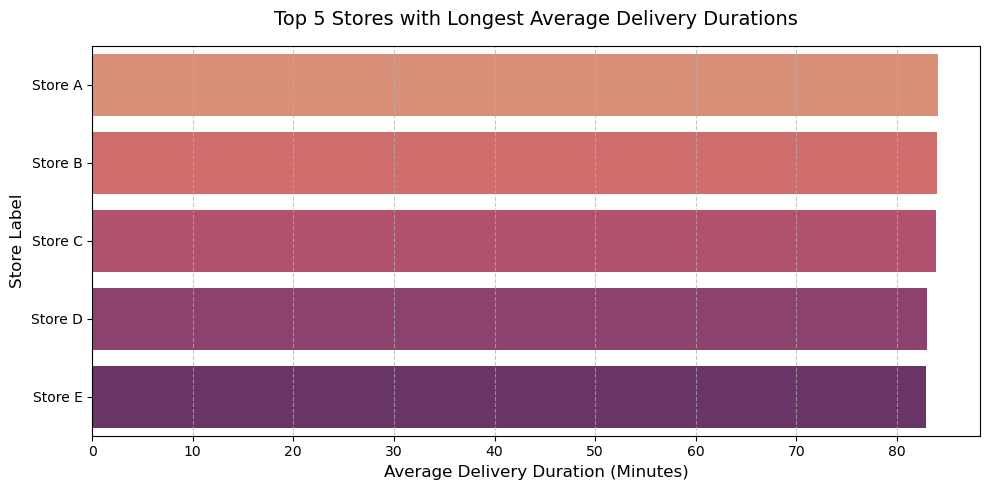

In [16]:
# Header statement as requested
print("Solution for basic level topic 10\n")

# 1. Filter out stores with fewer than 10 orders to ensure statistical reliability
min_orders = 10
store_counts = df_cleaned['store_id'].value_counts()
reliable_stores = store_counts[store_counts >= min_orders].index

# 2. Filter out extreme, unrealistic delivery durations (greater than 180 minutes)
df_filtered = df_cleaned[
    (df_cleaned['store_id'].isin(reliable_stores)) & 
    (df_cleaned['delivery_duration'] <= 180.0)
]

# 3. Calculate average delivery time per store and grab the top 5 longest
top_5_slowest_stores = df_filtered.groupby('store_id')['delivery_duration'].mean().sort_values(ascending=False).head(5)

# 4. Display the data summary mapping long IDs to simple business aliases
print("--- Top 5 Stores with Longest Average Delivery Times ---")
clean_labels = ['Store A', 'Store B', 'Store C', 'Store D', 'Store E']
store_mapping = {}

for i, (store_id, duration) in enumerate(top_5_slowest_stores.items()):
    alias = clean_labels[i]
    store_mapping[store_id] = alias  # Save the mapping for the chart labels
    print(f"{alias} (ID: {store_id[:8]}...): {duration:.2f} minutes")

# 5. Create a clean horizontal bar chart with the friendly Store names
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_5_slowest_stores.values, 
    y=clean_labels,  # Use clean aliases directly on the Y-axis
    hue=clean_labels,
    palette='flare', 
    legend=False
)

plt.title('Top 5 Stores with Longest Average Delivery Durations', fontsize=14, pad=15)
plt.xlabel('Average Delivery Duration (Minutes)', fontsize=12)
plt.ylabel('Store Label', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

### Medium Level Topics

Solution for medium level topic 1

--- Average Delivery Duration (Minutes) by Order Protocol ---
Protocol 7.0: 41.37 minutes
Protocol 5.0: 45.44 minutes
Protocol 3.0: 46.71 minutes
Protocol Unknown: 46.84 minutes
Protocol 2.0: 47.18 minutes
Protocol 4.0: 48.21 minutes
Protocol 1.0: 49.78 minutes
Protocol 6.0: 59.68 minutes


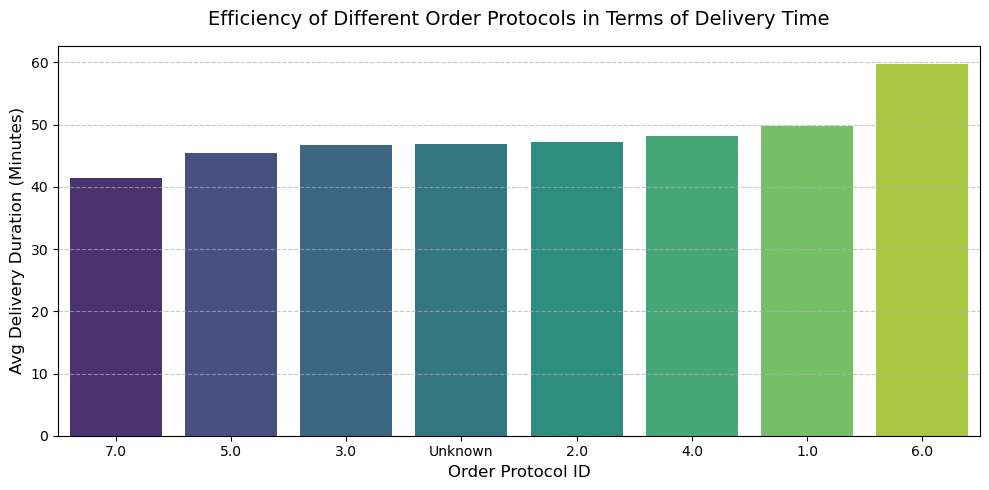

In [17]:
# Header statement as requested
print("Solution for medium level topic 1\n")

# 1. Filter out extreme outliers (> 3 hours) to ensure clean average calculations
df_medium = df_cleaned[df_cleaned['delivery_duration'] <= 180.0].copy()

# 2. Group by order_protocol and calculate the average delivery duration
protocol_efficiency = df_medium.groupby('order_protocol')['delivery_duration'].mean().sort_values()

# 3. Display the data summary in text format
print("--- Average Delivery Duration (Minutes) by Order Protocol ---")
for protocol, duration in protocol_efficiency.items():
    print(f"Protocol {protocol}: {duration:.2f} minutes")

# 4. Create a clean visualization mapped correctly to avoid warnings
plt.figure(figsize=(10, 5))
sns.barplot(
    x=protocol_efficiency.index.astype(str),  # Convert to string for discrete axis labels
    y=protocol_efficiency.values, 
    hue=protocol_efficiency.index.astype(str),
    palette='viridis', 
    legend=False
)

plt.title('Efficiency of Different Order Protocols in Terms of Delivery Time', fontsize=14, pad=15)
plt.xlabel('Order Protocol ID', fontsize=12)
plt.ylabel('Avg Delivery Duration (Minutes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 2

--- Average Order Subtotal Value by Market ---
Market ID 4.0: 2896.34
Market ID 1.0: 2744.39
Market ID Unknown: 2674.30
Market ID 2.0: 2632.50
Market ID 3.0: 2575.74
Market ID 6.0: 2512.99
Market ID 5.0: 2412.01


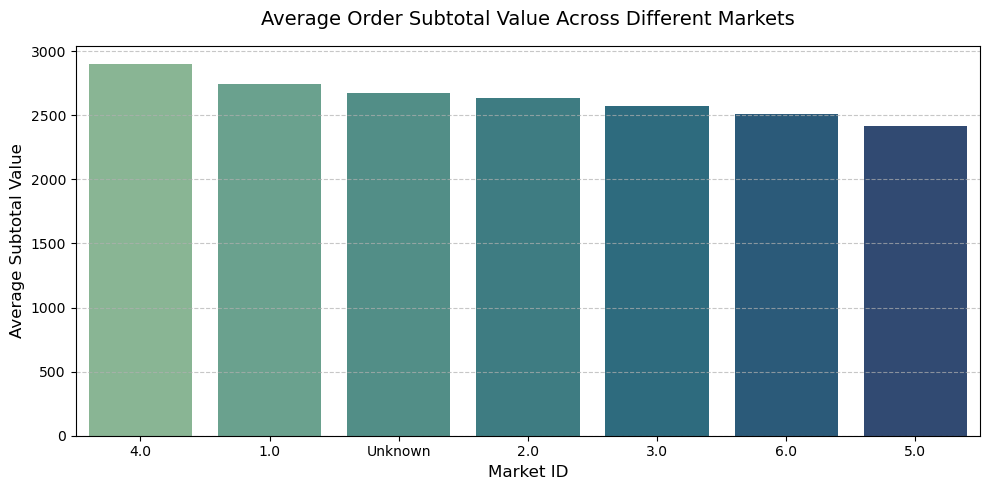

In [18]:
# Header statement as requested
print("Solution for medium level topic 2\n")

# 1. Group by market_id and calculate the average order subtotal value
market_value = df_cleaned.groupby('market_id')['subtotal'].mean().sort_values(ascending=False)

# 2. Display the data summary in text format
print("--- Average Order Subtotal Value by Market ---")
for market, avg_subtotal in market_value.items():
    print(f"Market ID {market}: {avg_subtotal:.2f}")

# 3. Create a clean bar plot structured to suppress Seaborn warnings
plt.figure(figsize=(10, 5))
sns.barplot(
    x=market_value.index.astype(str), 
    y=market_value.values, 
    hue=market_value.index.astype(str),
    palette='crest', 
    legend=False
)

plt.title('Average Order Subtotal Value Across Different Markets', fontsize=14, pad=15)
plt.xlabel('Market ID', fontsize=12)
plt.ylabel('Average Subtotal Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 3

Programmatically identified peak rush hours: [2, 1, 3]
Correlation between on-shift partners and delivery duration during peak hours: -0.0494



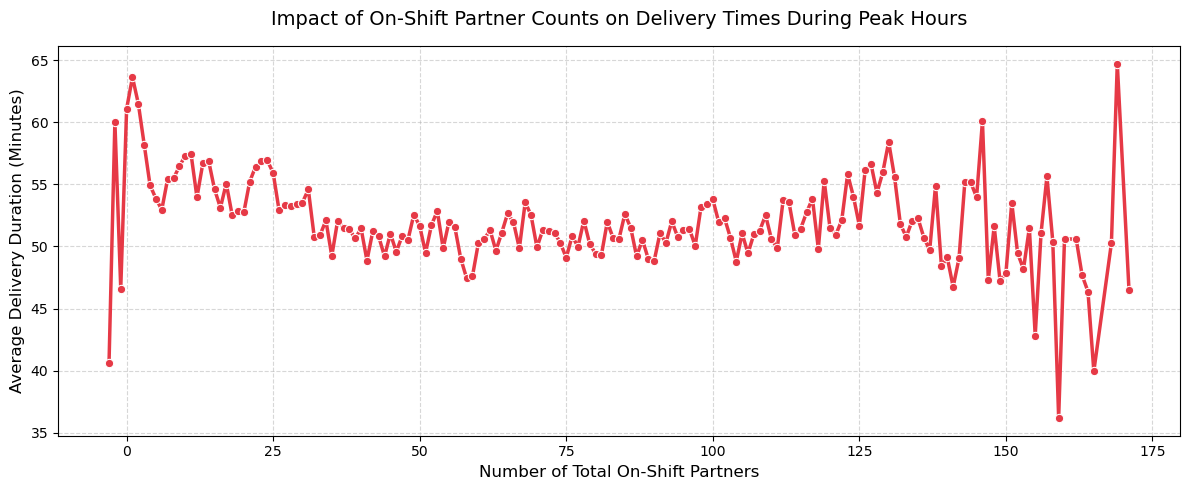

In [19]:
# Header statement as requested
print("Solution for medium level topic 3\n")

# 1. Programmatically identify the top 3 busiest hours of the day (Peak Hours)
peak_hours = df_cleaned['hour_of_the_day'].value_counts().head(3).index.tolist()
print(f"Programmatically identified peak rush hours: {peak_hours}")

# 2. Filter dataset for peak hours only and apply sensible delivery threshold
df_peak = df_cleaned[(df_cleaned['hour_of_the_day'].isin(peak_hours)) & (df_cleaned['delivery_duration'] <= 180.0)].copy()

# 3. Calculate correlation coefficient during rush hour window
peak_correlation = df_peak['total_onshift_partners'].corr(df_peak['delivery_duration'])
print(f"Correlation between on-shift partners and delivery duration during peak hours: {peak_correlation:.4f}\n")

# 4. Group data by partner count to map a clear trend line
partner_impact = df_peak.groupby('total_onshift_partners')['delivery_duration'].mean().sort_index()

# 5. Create a clean trend visualization
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=partner_impact.index, 
    y=partner_impact.values, 
    marker='o', 
    color='#e63946', 
    linewidth=2.5
)

plt.title('Impact of On-Shift Partner Counts on Delivery Times During Peak Hours', fontsize=14, pad=15)
plt.xlabel('Number of Total On-Shift Partners', fontsize=12)
plt.ylabel('Average Delivery Duration (Minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 4

--- Order Complexity Correlation Analysis ---
Correlation (Total Items vs. Delivery Time): 0.1202
Correlation (Distinct Items vs. Delivery Time): 0.1597

Insight: Distinct items have a stronger impact on delivery time than total item count.
This implies cooking/sorting variety creates more kitchen lag than simple bulk preparation.


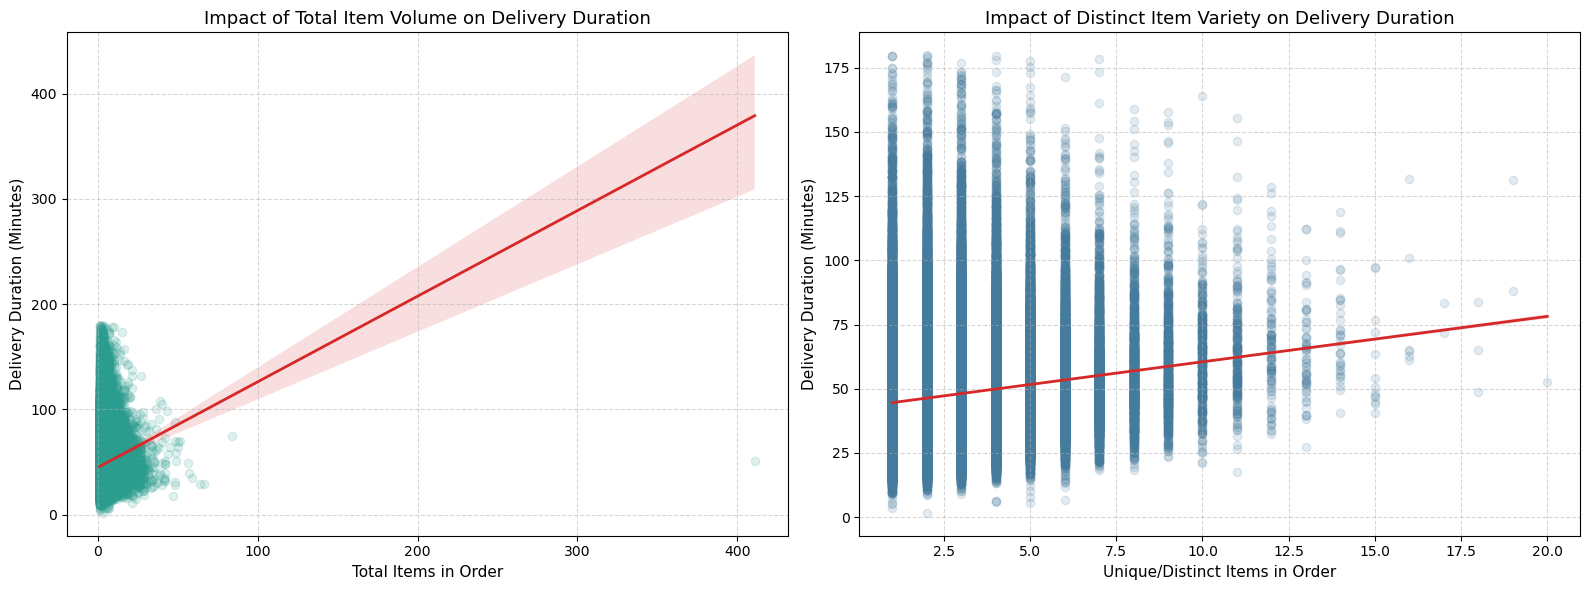

In [20]:
# Header statement as requested
print("Solution for medium level topic 4\n")

# 1. Filter out extreme outliers (> 3 hours) to ensure clean metric correlations
df_medium = df_cleaned[df_cleaned['delivery_duration'] <= 180.0].copy()

# 2. Compute correlation metrics against delivery duration
corr_total_items = df_medium['total_items'].corr(df_medium['delivery_duration'])
corr_distinct_items = df_medium['num_distinct_items'].corr(df_medium['delivery_duration'])

print("--- Order Complexity Correlation Analysis ---")
print(f"Correlation (Total Items vs. Delivery Time): {corr_total_items:.4f}")
print(f"Correlation (Distinct Items vs. Delivery Time): {corr_distinct_items:.4f}\n")

# Provide an analytical comparison
if corr_distinct_items > corr_total_items:
    print("Insight: Distinct items have a stronger impact on delivery time than total item count.")
    print("This implies cooking/sorting variety creates more kitchen lag than simple bulk preparation.")
else:
    print("Insight: Total item count has a stronger or equal impact compared to distinct items.")
    print("This implies mass scale preparation volume creates more delivery lag than item variety.")

# 3. Create side-by-side regression plots to visually contrast the two dimensions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Total Items
sns.regplot(
    ax=axes[0], data=df_medium, x='total_items', y='delivery_duration',
    scatter_kws={'alpha': 0.15, 'color': '#2a9d8f'}, line_kws={'color': '#d62828', 'linewidth': 2}
)
axes[0].set_title('Impact of Total Item Volume on Delivery Duration', fontsize=13)
axes[0].set_xlabel('Total Items in Order', fontsize=11)
axes[0].set_ylabel('Delivery Duration (Minutes)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot B: Distinct Items
sns.regplot(
    ax=axes[1], data=df_medium, x='num_distinct_items', y='delivery_duration',
    scatter_kws={'alpha': 0.15, 'color': '#457b9d'}, line_kws={'color': '#d62828', 'linewidth': 2}
)
axes[1].set_title('Impact of Distinct Item Variety on Delivery Duration', fontsize=13)
axes[1].set_xlabel('Unique/Distinct Items in Order', fontsize=11)
axes[1].set_ylabel('Delivery Duration (Minutes)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Display the graphs cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 5

--- Weekly Delivery Time Fluctuations (Averages) ---
Monday: 51.32 minutes
Tuesday: 46.21 minutes
Wednesday: 44.06 minutes
Thursday: 46.80 minutes
Friday: 44.66 minutes
Saturday: 49.97 minutes
Sunday: 48.34 minutes


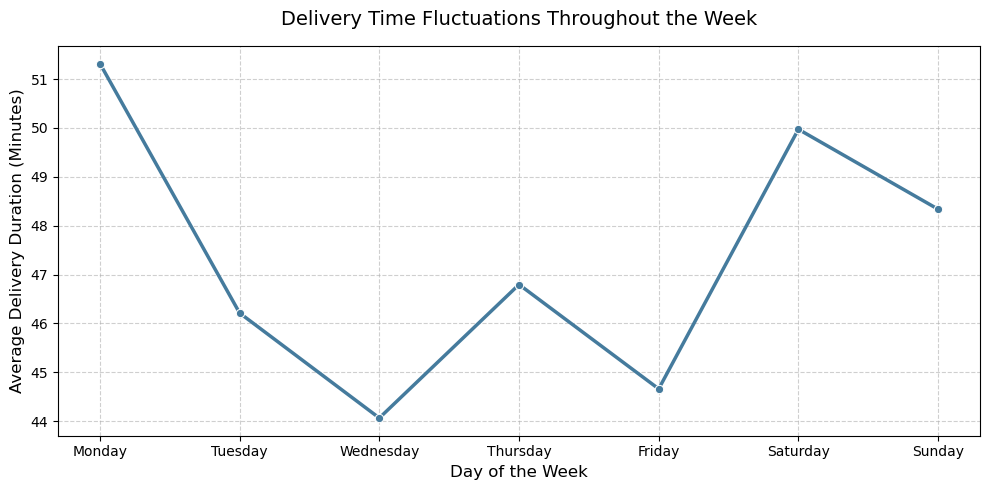

In [21]:
# Header statement as requested
print("Solution for medium level topic 5\n")

# 1. Filter out extreme outliers (> 3 hours) to ensure clean average calculations
df_medium = df_cleaned[df_cleaned['delivery_duration'] <= 180.0].copy()

# 2. Map day numbers to string names in chronological order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

# 3. Calculate average delivery times for each day of the week
weekly_fluctuations = df_medium.groupby('day_of_the_week')['delivery_duration'].mean().sort_index()
weekly_fluctuations.index = weekly_fluctuations.index.map(day_names)

# 4. Display the data summary in text format
print("--- Weekly Delivery Time Fluctuations (Averages) ---")
for day in day_order:
    if day in weekly_fluctuations.index:
        print(f"{day}: {weekly_fluctuations[day]:.2f} minutes")

# 5. Create a clean visualization to show trends and fluctuations clearly
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=weekly_fluctuations.index, 
    y=weekly_fluctuations.values, 
    marker='o', 
    color='#457b9d', 
    linewidth=2.5,
    sort=False
)

plt.title('Delivery Time Fluctuations Throughout the Week', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Delivery Duration (Minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 6

--- Item Price Range vs. Total Order Value Analysis ---
Correlation coefficient: 0.5096
Interpretation: Strong positive correlation. Orders containing a mix of high and low-priced items strongly drive higher subtotals.




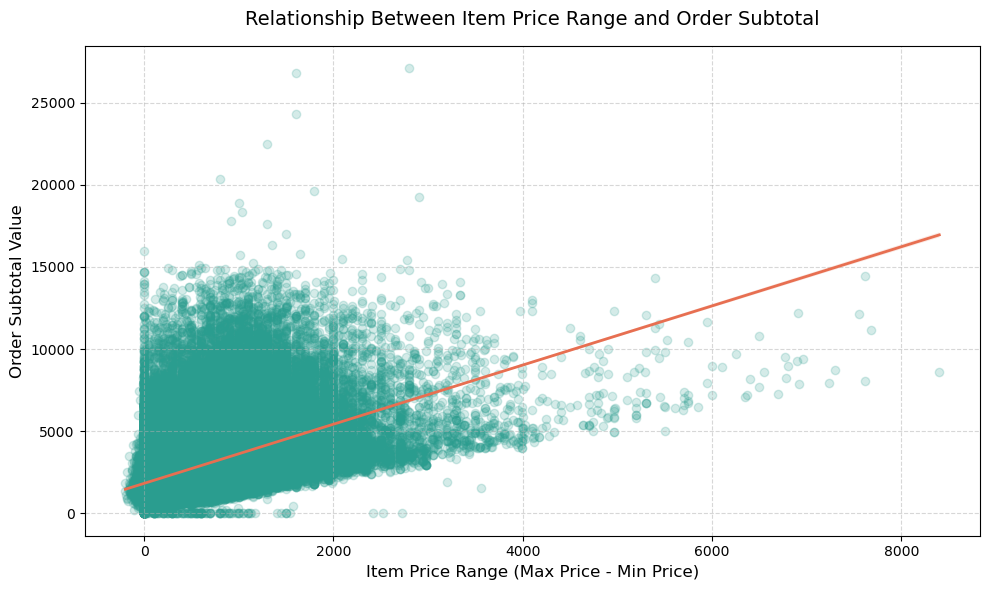

In [22]:
# Header statement as requested
print("Solution for medium level topic 6\n")

# 1. Calculate the item price range for each order
df_cleaned['item_price_range'] = df_cleaned['max_item_price'] - df_cleaned['min_item_price']

# 2. Compute the Pearson correlation coefficient between price range and subtotal
range_subtotal_corr = df_cleaned['item_price_range'].corr(df_cleaned['subtotal'])

print("--- Item Price Range vs. Total Order Value Analysis ---")
print(f"Correlation coefficient: {range_subtotal_corr:.4f}")

# Interpret the result
if range_subtotal_corr > 0.5:
    print("Interpretation: Strong positive correlation. Orders containing a mix of high and low-priced items strongly drive higher subtotals.")
elif range_subtotal_corr > 0.2:
    print("Interpretation: Moderate positive correlation. A wider variance in item pricing within a single order leans toward a higher subtotal.")
else:
    print("Interpretation: Weak or no correlation. Price range variety does not significantly impact the overall ticket size.")
print("\n")

# 3. Create a clean visualization to show the relationship
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned,
    x='item_price_range',
    y='subtotal',
    scatter_kws={'alpha': 0.2, 'color': '#2a9d8f'},
    line_kws={'color': '#e76f51', 'linewidth': 2}
)

plt.title("Relationship Between Item Price Range and Order Subtotal", fontsize=14, pad=15)
plt.xlabel("Item Price Range (Max Price - Min Price)", fontsize=12)
plt.ylabel("Order Subtotal Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 7

Overall Platform Average Subtotal: 2682.33

--- Top 10 Categories with Highest Proportion of Above-Average Orders ---
italian: 63.69% of orders are above average
sushi: 56.65% of orders are above average
japanese: 53.68% of orders are above average
thai: 51.39% of orders are above average
seafood: 51.14% of orders are above average
barbecue: 50.37% of orders are above average
pizza: 48.13% of orders are above average
greek: 45.88% of orders are above average
chinese: 45.07% of orders are above average
indian: 44.83% of orders are above average


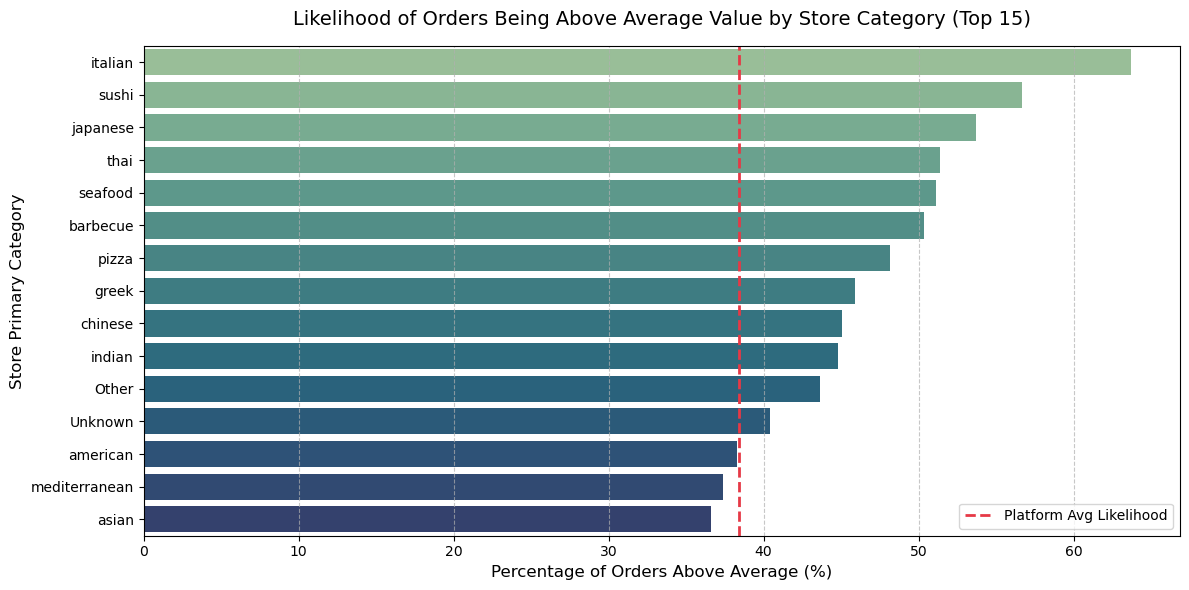

In [23]:
# Header statement as requested
print("Solution for medium level topic 7\n")

# 1. Determine the overall average order value (subtotal) across the whole dataset
overall_avg_subtotal = df_cleaned['subtotal'].mean()
print(f"Overall Platform Average Subtotal: {overall_avg_subtotal:.2f}\n")

# 2. Flag orders that are above the platform average
df_cleaned['is_above_average'] = df_cleaned['subtotal'] > overall_avg_subtotal

# 3. Calculate the proportion of high-value orders within each store category
category_high_value_prop = (
    df_cleaned.groupby('store_primary_category')['is_above_average']
    .mean()
    .sort_values(ascending=False)
)

# 4. Display the top 10 categories most likely to generate above-average order values
print("--- Top 10 Categories with Highest Proportion of Above-Average Orders ---")
for category, proportion in category_high_value_prop.head(10).items():
    print(f"{category}: {proportion * 100:.2f}% of orders are above average")

# 5. Create a clean visualization showing the top categories
plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_high_value_prop.head(15).values * 100, 
    y=category_high_value_prop.head(15).index, 
    hue=category_high_value_prop.head(15).index,
    palette='crest',
    legend=False
)

plt.axvline(x=df_cleaned['is_above_average'].mean() * 100, color='#e63946', linestyle='--', linewidth=2, label='Platform Avg Likelihood')
plt.title('Likelihood of Orders Being Above Average Value by Store Category (Top 15)', fontsize=14, pad=15)
plt.xlabel('Percentage of Orders Above Average (%)', fontsize=12)
plt.ylabel('Store Primary Category', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 8

--- Delivery Time Consistency (Standard Deviation) by Market ---
Market ID 1.0: Std Dev = 20.87 minutes
Market ID Unknown: Std Dev = 18.80 minutes
Market ID 6.0: Std Dev = 18.10 minutes
Market ID 3.0: Std Dev = 18.07 minutes
Market ID 4.0: Std Dev = 17.27 minutes
Market ID 5.0: Std Dev = 17.13 minutes
Market ID 2.0: Std Dev = 16.43 minutes

--- Top 10 Categories with Most Unpredictable Delivery Times (Highest Std Dev) ---
japanese: Std Dev = 20.12 minutes
dessert: Std Dev = 19.64 minutes
Unknown: Std Dev = 19.26 minutes
mediterranean: Std Dev = 18.98 minutes
sushi: Std Dev = 18.89 minutes
thai: Std Dev = 18.36 minutes
chinese: Std Dev = 18.28 minutes
pizza: Std Dev = 18.18 minutes
salad: Std Dev = 18.18 minutes
cafe: Std Dev = 18.14 minutes


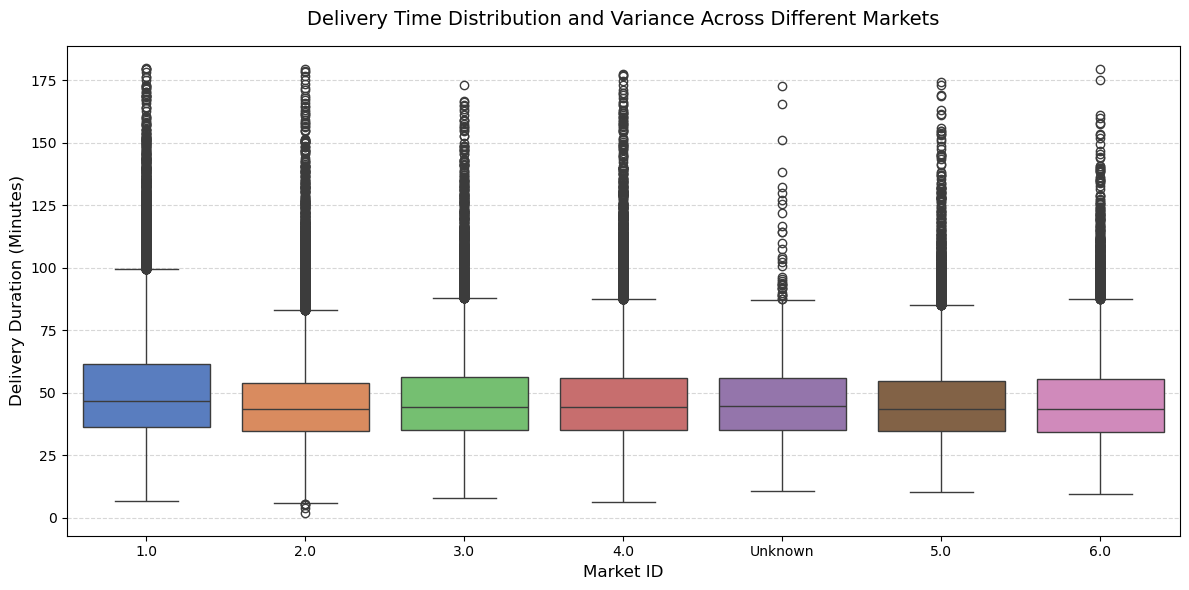

In [24]:
# Header statement as requested
print("Solution for medium level topic 8\n")

# 1. Filter out extreme outliers (> 3 hours) to ensure clean variance calculations
df_medium = df_cleaned[df_cleaned['delivery_duration'] <= 180.0].copy()

# 2. Calculate delivery time standard deviation by Market
market_variance = df_medium.groupby('market_id')['delivery_duration'].std().sort_values(ascending=False)

# 3. Calculate delivery time standard deviation by Category (Top 10 highest variance)
category_variance = df_medium.groupby('store_primary_category')['delivery_duration'].std().sort_values(ascending=False)

# 4. Display text summaries for both dimensions
print("--- Delivery Time Consistency (Standard Deviation) by Market ---")
for market, std_dev in market_variance.items():
    print(f"Market ID {market}: Std Dev = {std_dev:.2f} minutes")

print("\n--- Top 10 Categories with Most Unpredictable Delivery Times (Highest Std Dev) ---")
for category, std_dev in category_variance.head(10).items():
    print(f"{category}: Std Dev = {std_dev:.2f} minutes")

# 5. Create side-by-side boxplots to visualize the distribution spread across markets
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_medium, 
    x='market_id', 
    y='delivery_duration', 
    hue='market_id',
    palette='muted',
    legend=False
)

plt.title('Delivery Time Distribution and Variance Across Different Markets', fontsize=14, pad=15)
plt.xlabel('Market ID', fontsize=12)
plt.ylabel('Delivery Duration (Minutes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 9

--- Correlation between Driver Strain Ratio and Delivery Time by Market ---
Market ID 1.0: Correlation = 0.1413
Market ID 2.0: Correlation = 0.0186
Market ID 3.0: Correlation = 0.1785
Market ID 4.0: Correlation = 0.0265
Market ID Unknown: Correlation = 0.0845
Market ID 5.0: Correlation = 0.0870
Market ID 6.0: Correlation = 0.0204


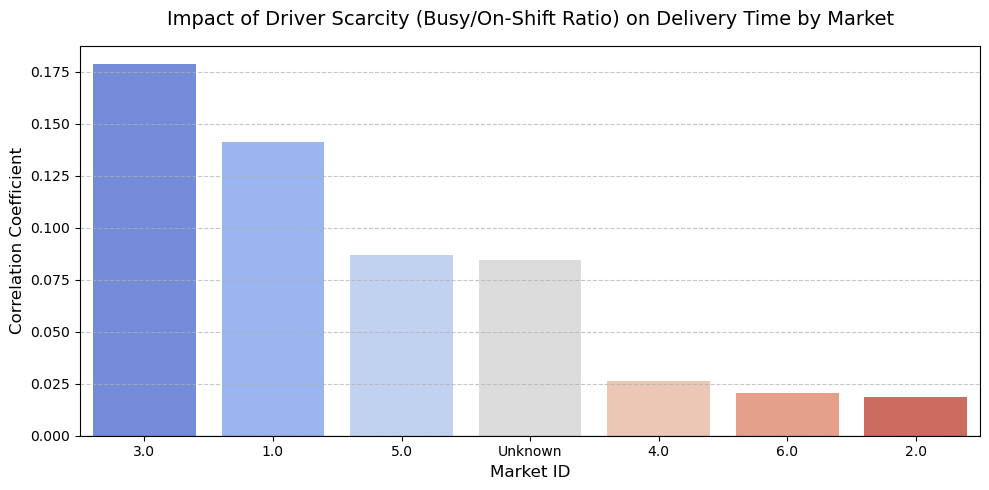

In [25]:
# Header statement as requested
print("Solution for medium level topic 9\n")

# 1. Filter out rows where on-shift partners is 0 to avoid division by zero errors
# Also apply a sensible threshold for realistic delivery times (< 180 minutes)
df_availability = df_cleaned[
    (df_cleaned['total_onshift_partners'] > 0) & 
    (df_cleaned['delivery_duration'] <= 180.0)
].copy()

# 2. Calculate the busyness ratio (High ratio = High capacity strain)
df_availability['busy_to_onshift_ratio'] = df_availability['total_busy_partners'] / df_availability['total_onshift_partners']

# 3. Calculate the correlation coefficient for each unique market
market_correlations = {}
unique_markets = df_availability['market_id'].unique()

print("--- Correlation between Driver Strain Ratio and Delivery Time by Market ---")
for market in unique_markets:
    # Filter for the specific market
    market_df = df_availability[df_availability['market_id'] == market]
    
    # Calculate Pearson correlation coefficient
    corr_val = market_df['busy_to_onshift_ratio'].corr(market_df['delivery_duration'])
    market_correlations[str(market)] = corr_val
    print(f"Market ID {market}: Correlation = {corr_val:.4f}")

# Convert to pandas series for clean sorting and plotting
market_corr_series = pd.Series(market_correlations).sort_values(ascending=False)

# 4. Create a clean visualization mapping the impact across regions
plt.figure(figsize=(10, 5))
sns.barplot(
    x=market_corr_series.index, 
    y=market_corr_series.values, 
    hue=market_corr_series.index,
    palette='coolwarm',
    legend=False
)

plt.title('Impact of Driver Scarcity (Busy/On-Shift Ratio) on Delivery Time by Market', fontsize=14, pad=15)
plt.xlabel('Market ID', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot cleanly
plt.tight_layout()
plt.show()

Solution for medium level topic 10

--- Operational Comparison (Using store_id profiling) ---
               total_items     subtotal
customer_type                          
First-Time        3.234982  2602.026502
Repeat            3.196256  2682.557258




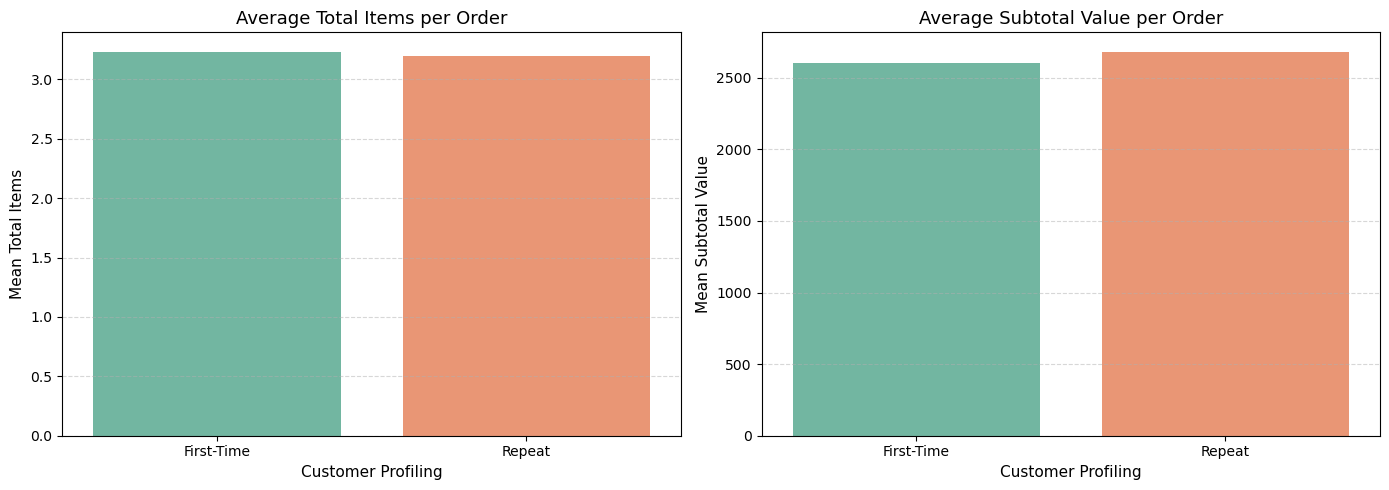

In [26]:
# Header statement as requested
print("Solution for medium level topic 10\n")

# 1. Determine the appropriate tracking ID (Check for customer/user id, fallback to store tracking)
if 'customer_id' in df_cleaned.columns:
    id_col = 'customer_id'
elif 'user_id' in df_cleaned.columns:
    id_col = 'user_id'
else:
    id_col = 'store_id'  # Fallback operational proxy metric

# 2. Count frequencies to flag first-time vs. repeat profiles
id_counts = df_cleaned[id_col].value_counts()

# Define first-time vs repeat cohorts based on transaction frequency signatures
first_time_ids = id_counts[id_counts == 1].index
repeat_ids = id_counts[id_counts > 1].index

# Map back to the dataframe
df_cleaned['customer_type'] = 'Repeat'
df_cleaned.loc[df_cleaned[id_col].isin(first_time_ids), 'customer_type'] = 'First-Time'

# 3. Calculate comparative metrics across total items and basket values
comparison_metrics = df_cleaned.groupby('customer_type')[['total_items', 'subtotal']].mean()

print(f"--- Operational Comparison (Using {id_col} profiling) ---")
print(comparison_metrics)
print("\n")

# 4. Create side-by-side comparative visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Total Items Contrast
sns.barplot(
    ax=axes[0],
    x=comparison_metrics.index,
    y=comparison_metrics['total_items'],
    hue=comparison_metrics.index,
    palette='Set2',
    legend=False
)
axes[0].set_title('Average Total Items per Order', fontsize=13)
axes[0].set_xlabel('Customer Profiling', fontsize=11)
axes[0].set_ylabel('Mean Total Items', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot B: Subtotal Ticket Contrast
sns.barplot(
    ax=axes[1],
    x=comparison_metrics.index,
    y=comparison_metrics['subtotal'],
    hue=comparison_metrics.index,
    palette='Set2',
    legend=False
)
axes[1].set_title('Average Subtotal Value per Order', fontsize=13)
axes[1].set_xlabel('Customer Profiling', fontsize=11)
axes[1].set_ylabel('Mean Subtotal Value', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()